In [1]:
# load the required libraries
import re
import os
import numpy as np
import pandas as pd
import h5py 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import math
from scipy.optimize import curve_fit
from scipy.stats import t
from scipy.ndimage import gaussian_filter1d
from scipy import stats
import json

## Config

In [2]:
# define stimulus list
## define stimulus list
#### 2025-04-21_EGCG
stimulus_lists_0421_EGCG = {
    'w1': ['c1_1', 'c1_2', 'c1_3', 'c1_4', 'c1_5'] * 3,
    'w2': ['c1_1', 'c1_2', 'c1_3', 'c1_4', 'c1_5'] * 3,
    'w3': ['c1_1', 'c1_2', 'c1_3', 'c1_4', 'c1_5'] * 3,
    'w4': ['c1_1', 'c1_2', 'c1_3', 'c1_4', 'c1_5'] * 3,
    'w5': ['c1_1', 'c1_2', 'c1_3', 'c1_4', 'c1_5'] * 3,
    'w6': ['c1_5', 'c1_4', 'c1_3', 'c1_2', 'c1_1'] * 3,  # Reversed and reorder the delta_F_over_F0
}
#### 2025-04-21_EGCG_high
stimulus_lists_0421_EGCG_high = {
    'w1': ['c1_4', 'c1_5', 'c1_6'] * 3,
    'w2': ['c1_4', 'c1_5', 'c1_6'] * 3,
}
#### 2025-0428_TF
stimulus_lists_0428_TF = {
    'w1': ['c3_1', 'c3_2', 'c3_3', 'c3_4', 'c3_5'] * 3,
    'w2': ['c3_1', 'c3_2', 'c3_3', 'c3_4', 'c3_5'] * 3,
    'w3': ['c3_1', 'c3_2', 'c3_3', 'c3_4', 'c3_5'] * 3,
    'w4': ['c3_1', 'c3_2', 'c3_3', 'c3_4', 'c3_5'] * 3,
    'w5': ['c3_1', 'c3_2', 'c3_3', 'c3_4', 'c3_5'] * 3,
    'w6': ['c3_1', 'c3_2', 'c3_3', 'c3_4', 'c3_5'] * 3,
    'w7': ['c3_1', 'c3_2', 'c3_3', 'c3_4', 'c3_5'] * 3,
}

#### 2025-0428_L_Theanine
stimulus_lists_0428_L_Theanine = {
    'w1': ['c1_3', 'c1_6', 'c1_3', 'c1_6', 'c3_3', 'c3_3', 'c2_2', 'c2_2', 'c4_1', 'c4_1'],
    'w2': ['c1_3', 'c1_6', 'c1_3', 'c1_6', 'c3_3', 'c3_3', 'c2_2', 'c2_2', 'c4_1', 'c4_1'],
    'w3': ['c1_3', 'c1_6', 'c1_3', 'c1_6', 'c3_3', 'c3_3', 'c2_2', 'c2_2', 'c4_1', 'c4_1'],
    'w4': ['c1_3', 'c1_6', 'c1_3', 'c1_6', 'c4_1', 'c4_1', 'c3_3', 'c3_3', 'c2_2', 'c2_2'],
    'w5': ['c1_3', 'c1_6', 'c1_3', 'c1_6', 'c4_1', 'c4_1', 'c3_3', 'c3_3', 'c2_2', 'c2_2'],
    'w6': ['c1_3', 'c1_6', 'c1_3', 'c1_6', 'c4_1', 'c4_1', 'c3_3', 'c3_3', 'c2_2', 'c2_2'],
}

In [3]:
# set folder_path
# folder_0421_EGCG = r"G:\LAB\DATA\result\20250421_EGCG"
# folder_0421_EGCG_high = r"G:\LAB\DATA\result\20250421_EGCG_high"
# folder_0428_TF = r"G:\LAB\DATA\result\20250428_TF"
# folder_0428_L_Theanine = r"G:\LAB\DATA\result\20250428_The"
folder_0421_EGCG = r"H:\Process_temporary\WJH\olfactory\ID\result\20250421_EGCG"
folder_0421_EGCG_high = r"H:\Process_temporary\WJH\olfactory\ID\result\20250421_EGCG_high"
folder_0428_TF = r"H:\Process_temporary\WJH\olfactory\ID\result\20250428_TF"
folder_0428_L_Theanine = r"H:\Process_temporary\WJH\olfactory\ID\result\20250428_The"

## Load worm data from infer result and ID annotation
- get stimulus interval info from output_volumes.xlsx
- get ID data from ID.xlsx
- get intensity data from HDF5 file
- detrend and save data in a dictionary

In [4]:
from data_load.get_stimulus_info import extract_intervals_from_excel
from data_load.load_worm_data import load_worm_ID, process_worm_data
# 0421_EGCG
info_excel = os.path.join(folder_0421_EGCG, 'output_volumes.xlsx')
experiment_info_0421_EGCG = extract_intervals_from_excel(info_excel)
ID_EGCG = load_worm_ID(folder_0421_EGCG + r'\ID0421EGCG.xlsx')

In [5]:
worm_data_0421_EGCG = {}
with h5py.File(folder_0421_EGCG + r'\20250421_EGCG.h5', 'r') as f:
    for key in f.keys():
        if key == 'w2' or key == 'w3':
            worm_data_0421_EGCG[key] = process_worm_data(
                key, f, experiment_info_0421_EGCG, ID_EGCG, 
                stimulus_lists=stimulus_lists_0421_EGCG
            )

In [6]:
# 0428_Theanine
info_excel = os.path.join(folder_0428_L_Theanine, 'output_volumes.xlsx')
experiment_info_0428_L_Theanine = extract_intervals_from_excel(info_excel)
ID_Theanine = load_worm_ID(folder_0428_L_Theanine + r'\ID0428_The.xlsx')

In [7]:
## For 2025_0428_L_Theanine
worm_data_0428_L_Theanine = {}
with h5py.File(folder_0428_L_Theanine + r'\20250428_The.h5', 'r') as f:
    for key in f.keys():
        if key == 'w2' or key == 'w3':
            worm_data_0428_L_Theanine[key] = process_worm_data(
                key, f, experiment_info_0428_L_Theanine,
                ID_Theanine, stimulus_lists_0428_L_Theanine,
            )
        elif key == 'w4' or key == 'w5' or key == 'w6':
            # 处理w4的特殊情况
            worm_data_0428_L_Theanine[key] = process_worm_data(
                key, f, experiment_info_0428_L_Theanine,
                ID_Theanine, stimulus_lists_0428_L_Theanine,
                stimulus_sort=[0, 1, 2, 3, 6, 7, 8,9,4,5], buffer_sort=[0, 1, 2, 3,4,7,8,9,10,5,6],
                need_sorting=True
            )

## Divide wormdata into segments
- 1 segment represent 40s data(30vols before stimulus and 120vols after stimulus, stimulus intervals are set to 50 vols)
- segment data is saved as dictionary

In [8]:
from data_load.process_worm_data import extract_neuron_groups

neuron_segment_dict_0428_L_Theanine, neuron_groups_0428_L_Theanine = extract_neuron_groups(worm_data_0428_L_Theanine)

In [9]:
from data_load.process_worm_data import per_worm_zscore
neuron_segments_dict_0428_L_Theanine,_ = per_worm_zscore(neuron_segment_dict_0428_L_Theanine)

In [10]:
from data_load.process_worm_data import reorganize_neuron_segments
neuron_segments_dict_0428_L_Theanine_reorganized = reorganize_neuron_segments(
    neuron_segment_dict_0428_L_Theanine, 
    date='2025-04-28',
)


In [11]:
from data_load.process_worm_data import merge_multiple_dicts
all_neuron_segments = merge_multiple_dicts(neuron_segments_dict_0428_L_Theanine_reorganized)

In [12]:
import copy
neuron_segments_dict = copy.deepcopy(all_neuron_segments)
neuron_groups = copy.deepcopy(neuron_groups_0428_L_Theanine)

## plot

In [13]:
import json
with open(r'H:\Process_temporary\WJH\sensory_pipeline_python\data_load\config\compound_info.json', 'r') as f:
    compounds = json.load(f)

In [28]:
from result_plot.lineplot import plot_neurons_to_pdf
output_pdf = r'H:\Process_temporary\WJH\olfactory\ID\result\20250428_The\neuron_segments.pdf'
plot_neurons_to_pdf(neuron_segments_dict, compounds,output_pdf)


PDF saved to H:\Process_temporary\WJH\olfactory\ID\result\20250428_The\neuron_segments.pdf


'H:\\Process_temporary\\WJH\\olfactory\\ID\\result\\20250428_The\\neuron_segments.pdf'

In [14]:
from result_plot.radar_heatmap_plot import compare_compounds_and_dilutions, heatmap_plot
output_folder = r"H:\Process_temporary\WJH\olfactory\ID\result\20250428_The\visulization_1"
os.makedirs(output_folder, exist_ok=True)
# compare_compounds_and_dilutions(neuron_segments_dict, compounds, output_folder, if_combine=True)

In [16]:
neuron_segments_dict

{'ADFL': {'c1_3': [{'worm_key': 'w3',
    'segment_index': 0,
    'deltaFoverF_0': array([-7.01538473e-03, -1.26628447e-02, -1.54013429e-02, -1.30633265e-02,
           -1.22619299e-02, -1.07975965e-02, -3.34446365e-03, -8.36419058e-04,
           -7.58715114e-03, -1.11433230e-02, -5.99434786e-03, -4.94072621e-04,
            2.28449964e-04, -3.04276450e-03, -5.69865527e-03, -5.88593585e-03,
           -2.46580364e-03,  3.93849425e-03,  2.53132079e-03, -4.97737387e-03,
           -5.23694325e-03, -5.09333797e-04,  1.62378873e-03,  2.03715847e-03,
            6.08613668e-03,  8.81038327e-03,  1.66149368e-03, -9.09564178e-03,
           -1.31814536e-02, -1.24654695e-02, -8.20533838e-03, -5.67889120e-03,
           -5.24862437e-03, -4.39297035e-03, -4.66396101e-03, -1.80780562e-03,
            3.02032591e-03,  4.35008015e-03,  2.66731600e-03,  8.15823150e-04,
           -4.50793421e-04, -2.52475351e-04,  8.67557173e-05, -2.47771782e-03,
           -4.91118105e-03, -4.35818359e-03, -3.1891

After combining L/R neurons: 11 neurons


TypeError: Image data of dtype object cannot be converted to float

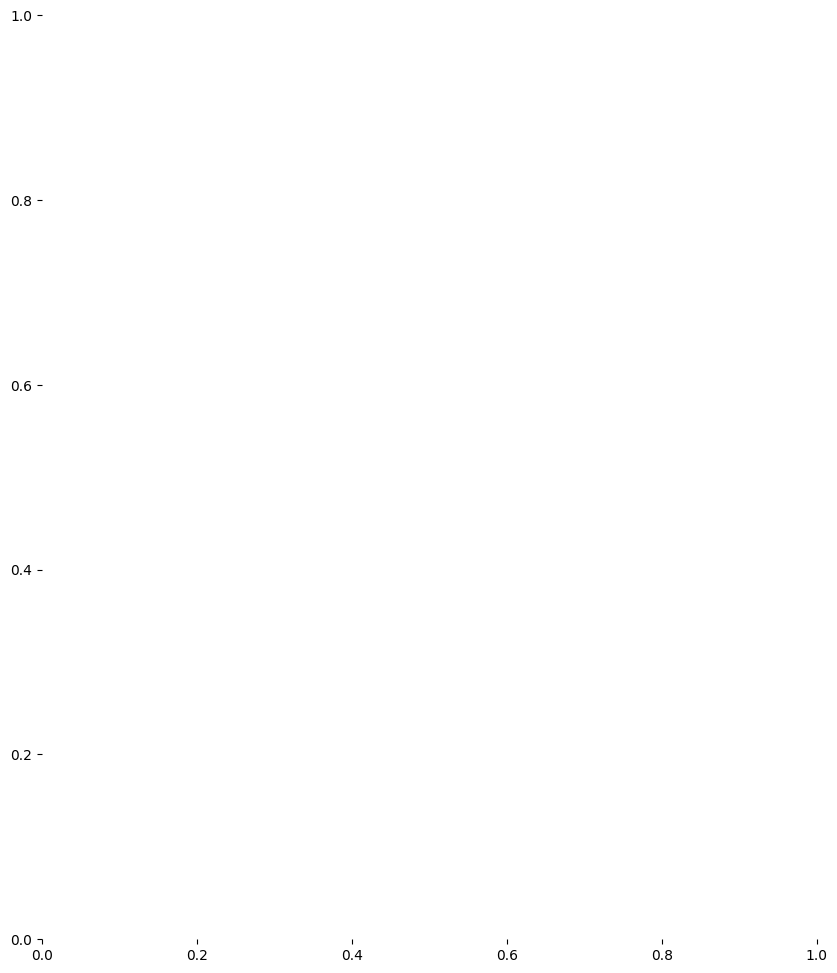

In [17]:
heatmap_plot(neuron_segments_dict, compounds, output_folder, if_combine=True)